# Hospital Operations Intelligence Platform

## Notebook 04: Readmission Prediction

### Business objective

Predict 30-day readmission risk early enough for administrators and care teams
to prioritize discharge review and follow-up capacity.

### Target

`readmitted_30d` (binary classification)

### Experiments

Logistic Regression, Random Forest, XGBoost, LightGBM, optional CatBoost, and
GridSearchCV tuning. Evaluation emphasizes ROC AUC, recall, precision, and F1
rather than accuracy alone because readmission is imbalanced.

## 1. Imports and ML dataset

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
INTERIM = ROOT / "datasets" / "interim"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
EXPERIMENT_MODELS = MODELS / "experiments"
EXPERIMENT_REPORTS = REPORTS / "experiments"
for folder in [INTERIM, PROCESSED, MODELS, REPORTS, EXPERIMENT_MODELS, EXPERIMENT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, RocCurveDisplay, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline

from train_models import READMISSION_FEATURES, group_split, preprocessor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
data_path = INTERIM / "notebook_model_features.csv"
data = pd.read_csv(data_path)
experiment = data.sample(min(30000, len(data)), random_state=42)
X = experiment[READMISSION_FEATURES]
y = experiment["readmitted_30d"].astype(int)
X_train, X_test, y_train, y_test, split_audit = group_split(
    X, y, experiment["patient_id"]
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Readmission prevalence:", f"{y.mean():.2%}")
print("Patient overlap:", split_audit["patient_overlap"])

Train: (24032, 15) Test: (5968, 15)
Readmission prevalence: 11.95%
Patient overlap: 0


## 2. Build candidate models

In [5]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000, class_weight="balanced"
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight="balanced",
        random_state=42, n_jobs=-1,
    ),
}

try:
    from xgboost import XGBClassifier
    models["xgboost"] = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.08,
        subsample=0.9, eval_metric="logloss", random_state=42,
    )
except ImportError:
    print("XGBoost is not installed.")

try:
    from lightgbm import LGBMClassifier
    models["lightgbm"] = LGBMClassifier(
        n_estimators=100, learning_rate=0.08, random_state=42, verbose=-1
    )
except ImportError:
    print("LightGBM is not installed.")

try:
    from catboost import CatBoostClassifier
    models["catboost"] = CatBoostClassifier(
        iterations=100, depth=5, learning_rate=0.08,
        verbose=False, random_seed=42,
    )
except ImportError:
    print("CatBoost is optional and unavailable in this Python environment.")

## 3. Train and evaluate

In [6]:
results = []
fitted_models = {}
for name, estimator in models.items():
    pipeline = Pipeline(
        [("prep", preprocessor(X_train)), ("model", estimator)]
    )
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)[:, 1]
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "f1": f1_score(y_test, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probability),
        }
    )
    fitted_models[name] = pipeline

results = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results)

,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.677949,0.223757,0.673130,0.335867,0.735878
4,catboost,0.880362,0.568966,0.045706,0.084615,0.735370
2,xgboost,0.880027,0.550000,0.045706,0.084399,0.735324
3,lightgbm,0.879021,0.500000,0.044321,0.081425,0.727819
1,random_forest,0.789209,0.279967,0.472299,0.351546,0.724633


## 4. Hyperparameter tuning

In [7]:
tuning_pipeline = Pipeline(
    [
        ("prep", preprocessor(X_train)),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced", random_state=42, n_jobs=-1
            ),
        ),
    ]
)
parameter_grid = {
    "model__n_estimators": [80, 120],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [1, 3],
}
grid = GridSearchCV(
    tuning_pipeline,
    parameter_grid,
    scoring="roc_auc",
    cv=GroupKFold(n_splits=3),
    n_jobs=-1,
    verbose=1,
)
grid.fit(
    X_train,
    y_train,
    groups=experiment.loc[X_train.index, "patient_id"],
)
tuned_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)
print("Cross-validated ROC AUC:", round(grid.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 120}
Cross-validated ROC AUC: 0.7256


## 5. Diagnostic visualizations

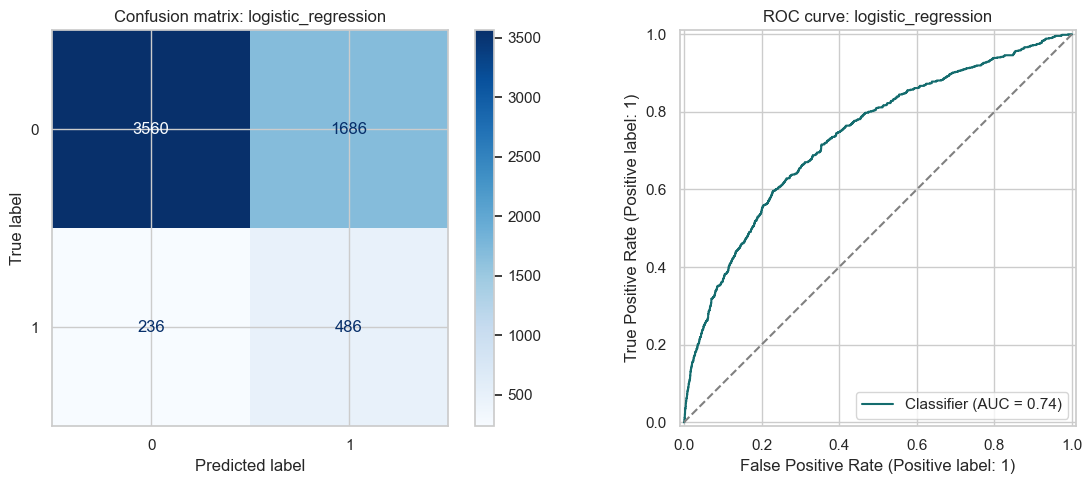

In [8]:
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_prediction = best_model.predict(X_test)
best_probability = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_prediction, cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion matrix: {best_name}")
RocCurveDisplay.from_predictions(
    y_test, best_probability, ax=axes[1], color="#146C6E"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title(f"ROC curve: {best_name}")
plt.tight_layout()
plt.show()

## 6. Save model and metrics

In [9]:
tuned_probability = tuned_model.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, tuned_probability)
if tuned_auc >= results.iloc[0]["roc_auc"]:
    selected_model = tuned_model
    selected_name = "tuned_random_forest"
else:
    selected_model = best_model
    selected_name = best_name

joblib.dump(selected_model, EXPERIMENT_MODELS / "readmission_notebook.pkl")
results.to_csv(EXPERIMENT_REPORTS / "readmission_metrics.csv", index=False)
print("Selected:", selected_name)
print("Saved:", EXPERIMENT_MODELS / "readmission_notebook.pkl")

Selected: logistic_regression
Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\models\experiments\readmission_notebook.pkl


## Business conclusions

- ROC AUC is the primary ranking metric; recall should be tuned to available
  follow-up capacity.
- A high-risk flag is a prioritization aid, not a diagnosis.
- LOS, comorbidity, laboratory abnormality, prior admissions, and complexity
  require explainability review before intervention.
- Threshold calibration and external hospital validation are required before deployment.